# Laboratorio 07 - Taller: Fundamentos de Machine Learning y Redes Neuronales

## Introducción

En este taller exploraremos el uso de TensorFlow y Keras para el diseño y entrenamiento de redes neuronales perceptrón multicapa. Utilizaremos el conjunto de datos **Pizza or not pizza?** para construir un modelo capaz de clasificar imágenes de acuerdo a su clase.

## Contenido del Taller

1. **Preprocesamiento de Datos**  
   - Implemente técnicas de preprocesamiento como normalización, estandarización y aumentación de datos utilizando TensorFlow y Keras.  
   - Adicionalmente, puede aplicar cualquier procesamiento explicado previamente en el curso.  
   - Justifique cada técnica de preprocesamiento seleccionada y analice su impacto en el desempeño del modelo.

2. **Construcción de un Modelo de Red Neuronal Perceptrón Multicapa**  
   - Desarrolle un modelo de red neuronal perceptrón multicapa utilizando Keras.  
   - Discuta la elección de la arquitectura, detallando el número de capas, la cantidad de neuronas por capa y las funciones de activación empleadas.

3. **Definición de Funciones de Callbacks para Monitorear el Entrenamiento**  
   - Implemente callbacks en TensorFlow y Keras para monitorear el proceso de entrenamiento.  
   - Explique cómo estos callbacks pueden ayudar a identificar problemas como el sobreajuste o un entrenamiento insuficiente.  
   - Justifique la selección y configuración de cada callback.

4. **Entrenamiento y Exploración de Resultados**  
   - Detalle el proceso de entrenamiento, incluyendo la elección de la tasa de aprendizaje, el optimizador y la función de pérdida.  
   - Analice los resultados obtenidos utilizando métricas de desempeño como precisión, recall y F1-score.  
   - Compare los resultados y discuta posibles mejoras en el modelo.

## 1. Preprocesamiento de los datos

In [2]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import cv2
import json

1.1 Descarga y Preparación del Dataset

In [3]:
# Cargar credenciales desde 'kaggle.json'
with open('./kaggle.json') as f:
    kaggle_credentials = json.load(f)

os.environ['KAGGLE_USERNAME'] = kaggle_credentials['username']
os.environ['KAGGLE_KEY'] = kaggle_credentials['key']

# Autenticación y descarga del dataset
from kaggle.api.kaggle_api_extended import KaggleApi
api = KaggleApi()
api.authenticate()
api.dataset_download_files('carlosrunner/pizza-not-pizza', path='data', unzip=True)

Dataset URL: https://www.kaggle.com/datasets/carlosrunner/pizza-not-pizza


1.2 Exploración de Imágenes

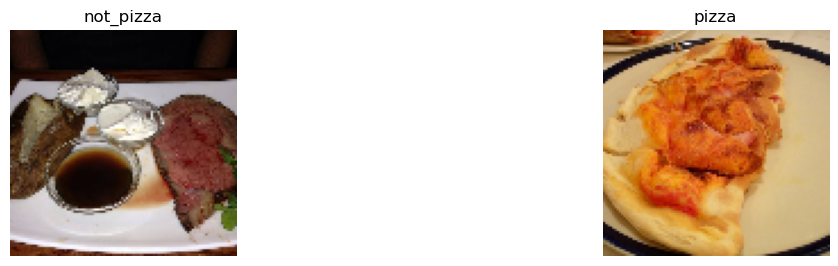

In [4]:
# Directorio de imágenes y categorías
data_dir = 'data/pizza_not_pizza'

pizza_categories = [
    d for d in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, d))
]

# Visualización de imágenes originales
plt.figure(figsize=(12, 10))

for i, category in enumerate(pizza_categories):
    folder = os.path.join(data_dir, category)
    
    # Asegurarse de que haya imágenes
    images = os.listdir(folder)
    if len(images) == 0:
        continue
    
    image_file = images[0]
    img_path = os.path.join(folder, image_file)

    # Cargar imagen
    img = keras.preprocessing.image.load_img(img_path, target_size=(100, 100))
    img_array = keras.preprocessing.image.img_to_array(img) / 255.0

    plt.subplot(4, 2, i+1)
    plt.imshow(img_array)
    plt.title(category)
    plt.axis('off')

plt.tight_layout()
plt.show()

1.3 Preparación de Datos y División en Entrenamiento, Validación y Test

Cargamos las imágenes en un df de pandas para hacer el split train/val/test usando sklearn.

In [5]:
# Recopilación de rutas y etiquetas
filepaths = [os.path.join(dp, f) for dp, dn, filenames in os.walk(data_dir)
             for f in filenames if os.path.splitext(f)[1].lower() in ['.png','.jpg','.jpeg']]
labels = [os.path.split(os.path.split(path)[0])[1] for path in filepaths]

# Crear un DataFrame con rutas y etiquetas
data_df = pd.DataFrame({'filepath': filepaths, 'label': labels})

# División de datos: 70% entrenamiento, 30% para validación y test (10% test, 20% validación)
from sklearn.model_selection import train_test_split
train_df, test_val_df = train_test_split(data_df, test_size=0.3, random_state=42)
test_df, val_df = train_test_split(test_val_df, test_size=2/3, random_state=42)

print("Total de imágenes:", len(data_df))
print("Entrenamiento:", len(train_df))
print("Validación:", len(val_df))
print("Test:", len(test_df))

Total de imágenes: 1966
Entrenamiento: 1376
Validación: 394
Test: 196


1.4 Procesamiento y Generadores de Imágenes

In [6]:
# Generador para el conjunto de entrenamiento con data augmentation
train_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True
)

# Generador para validación y test (solo reescala)
test_val_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)

# Crear los generadores a partir de los DataFrames
train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=(100, 100), batch_size=32
)
val_gen = test_val_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=(100, 100), batch_size=32, shuffle=False
)
test_gen = test_val_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label',
    target_size=(100, 100), batch_size=32, shuffle=False
)

Found 1376 validated image filenames belonging to 2 classes.
Found 394 validated image filenames belonging to 2 classes.
Found 196 validated image filenames belonging to 2 classes.


Se aplicaron técnicas de preprocesamiento para mejorar el desempeño del modelo. En primer lugar, se utilizó normalización mediante el reescalado de los valores de píxeles al rango [0,1], lo cual facilita la convergencia durante el entrenamiento. Además, se implementó aumentación de datos en el conjunto de entrenamiento mediante rotaciones y volteos horizontales, con el fin de incrementar la variabilidad de las imágenes y reducir el sobreajuste. No se aplicó estandarización, ya que la normalización fue suficiente para estabilizar el entrenamiento en este caso.

## 2. Construcción de un Modelo de Red Neuronal Perceptrón Multicapa

In [7]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout

print(len(pizza_categories))

model = Sequential([
    Flatten(input_shape=(100, 100, 3)),
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(256, activation='relu'),
    Dense(len(pizza_categories), activation='sigmoid')
])

# Resumen del modelo y su arquitectura
model.summary()

2


/opt/anaconda3/envs/notebook_1/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 30000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    15,360,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,492,354 (59.10 MB)

 Trainable params: 15,492,354 (59.10 MB)

 Non-trainable params: 0 (0.00 B)

La arquitectura seleccionada se justifica como una solución adecuada para un problema de clasificación binaria en una etapa inicial de experimentación, priorizando simplicidad y eficiencia computacional, en comparación a arquitecturas avanzadas como CNN. La arquitectura se compone de una capa de entrada, dos capas densas ocultas con un dropout intermedio de 0.2 para evitar overfitting, y una capa de salida de dos neuronas debido a que es un problema de clasificación binario.

El uso de capas densas permite modelar relaciones no lineales a partir de las características extraídas de las imágenes, mientras que la inclusión de regularización mediante Dropout contribuye a mitigar el sobreajuste dado el alto número de parámetros inherente a este tipo de modelos. Se eligió ReLU como función de activación en las capas ocultas, porque permite aprender relaciones no lineales de forma eficiente y acelera la convergencia durante el entrenamiento. Además, reduce el problema del desvanecimiento del gradiente lo que facilita optimizar redes con varias capas. En la capa de salida hay una función de activación sigmoide que permite calcular las probabilidades de clase.

El total de parámetros entrenables es de 15,492,354 ; de los cuales dense 15,360,512 son de la primera capa oculta, 131,328 son de la segunda capa oculta y 514 son de la capa de salida.

## 3. Definición de Funciones de Callbacks para Monitorear el Entrenamiento

In [8]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

model_checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True,
                                   monitor='val_loss', mode='min')
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, mode='min')

callbacks = [model_checkpoint, early_stopping, reduce_lr]

**Definición de Callbacks:**

Los callbacks en TensorFlow/Keras son funciones que se ejecutan en momentos específicos durante el entrenamiento (inicio, fin de época, fin de entrenamiento). Permiten monitorear el proceso de aprendizaje, guardar modelos, ajustar parámetros dinámicamente y detener el entrenamiento cuando se cumplen condiciones predefinidas, facilitando controlar el proceso sin modificar su código base.

El uso de callbacks en esta arquitectura resulta una decisión adecuada, ya que permite compensar las limitaciones inherentes a un modelo MLP aplicado a imágenes, el cual tiende a sobreajustarse debido al alto número de parámetros.

**Callbacks Utilizados**

1. **EarlyStopping:**
   - Detiene entrenamiento cuando val_loss no mejora
   - Evita overfitting y desperdicio de recursos computacionales
   - Recupera los pesos del mejor modelo encontrado

2. **ModelCheckpoint:**
   - Guarda el mejor modelo durante el entrenamiento basado en val_loss
   - Permite recuperar el mejor modelo aunque el entrenamiento continúe degradándose posteriormente

3. **ReduceLROnPlateau:**
   - Reduce la tasa de aprendizaje cuando val_loss se estanca
   - Permite ajustes finos cuando el modelo se ha ralentizado
   - Facilita escapar de mínimos locales

**Justificación de Parámetros**

- **monitor='val_loss'** (EarlyStopping, ModelCheckpoint, ReduceLROnPlateau): Monitoreamos pérdida de validación (métrica más representativa de generalización)
- **patience=10** (EarlyStopping): Esperamos 10 épocas sin mejora antes de detener (balance entre exploración y eficiencia)
- **patience=5** (ReduceLROnPlateau): Reducimos learning rate después de 5 épocas sin progreso (más agresivo que EarlyStopping para permitir ajustes antes de detener)
- **factor=0.1** (ReduceLROnPlateau): Multiplicamos learning rate por 0.1, reduciendo de forma agresiva el learning rate.
- **mode='min'** (EarlyStopping, ModelCheckpoint, ReduceLROnPlateau): Indicamos que monitoreamos una métrica donde "menor es mejor" (val_loss). Con mode='min', los callbacks buscan minimizar val_loss. Si monitoreáramos una métrica donde "mayor es mejor" (como val_accuracy), usaríamos mode='max'.

**Fuente:**
GeeksforGeeks. (s.f.). "Deep Learning - TF Keras Callbacks Callback TensorFlow Callbacks".
Recuperado de: https://www.geeksforgeeks.org/deep-learning/tf-keras-callbacks-callback-tensorflow-callbacks/

## 4. Entrenamiento y Exploración de Resultados

**Justificación de Configuración de Entrenamiento**

1. Optimizador Adam

Adam es un método de descenso de gradiente estocástico basado en estimación adaptativa de momentos de primer y segundo orden. Según Kingma et al. (2014), el método es "computacionalmente eficiente, requiere poca memoria, es invariante al reescalado diagonal de gradientes y es apropiado para problemas grandes en términos de datos y parámetros". Se utiliza la tasa de aprendizaje por default del optimizador (0.001).

2. Función de Pérdida: Binary Crossentropy

Para nuestro problema de clasificación binaria (pizza vs no-pizza), Binary Crossentropy es la función de pérdida estándar. Penaliza las predicciones incorrectas proporcionalmente a su confianza, lo que permite que el modelo aprenda a diferenciar las dos clases de manera efectiva.

3. Métrica: Accuracy

Seleccionamos accuracy como métrica de desempeño porque nuestro problema no tiene penalizaciones diferenciadas por tipo de error (falso positivo o falso negativo). Todos los errores tienen igual importancia, por lo que accuracy (porcentaje de predicciones correctas) es la métrica estándar e interpretable para este caso.

4. Número de Épocas: 50

El número de épocas fue escogido experimentalmente.


**Fuentes:**

- Kingma, D. P., & Ba, J. (2014). "Adam: A Method for Stochastic Optimization". arXiv preprint arXiv:1412.6980. https://arxiv.org/abs/1412.6980
- TensorFlow Documentation - Adam Optimizer. https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam

In [9]:
model.compile(optimizer='adam', # Determina cómo se actualizan los pesos de la red durante el entrenamiento
              loss='binary_crossentropy', # Mide qué tan bien el modelo está haciendo predicciones
              metrics=['accuracy']) # Monitorear el rendimiento del modelo durante el entrenamiento y la prueba

In [10]:
with tf.device('/device:GPU:0'):
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=50,
        callbacks=callbacks
    )

Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5208 - loss: 4.6371

43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.5676 - loss: 2.6483 - val_accuracy: 0.6396 - val_loss: 0.8368 - learning_rate: 0.0010
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5990 - loss: 0.8751

43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.5916 - loss: 0.8180 - val_accuracy: 0.5964 - val_loss: 0.6682 - learning_rate: 0.0010
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.6192 - loss: 0.6812 - val_accuracy: 0.6574 - val_loss: 0.6711 - learning_rate: 0.0010
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6320 - loss: 0.6910

43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.6257 - loss: 0.6798 - val_accuracy: 0.6193 - val_loss: 0.6493 - learning_rate: 0.0010
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6268 - loss: 0.6573

43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.6388 - loss: 0.6438 - val_accuracy: 0.6675 - val_loss: 0.6213 - learning_rate: 0.0010
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.6330 - loss: 0.6471 - val_accuracy: 0.5330 - val_loss: 0.6902 - learning_rate: 0.0010
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.6206 - loss: 0.6527 - val_accuracy: 0.6548 - val_loss: 0.6449 - learning_rate: 0.0010
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.6330 - loss: 0.6495 - val_accuracy: 0.6726 - val_loss: 0.6224 - learning_rate: 0.0010
Epoch 9/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6494 - loss: 0.6389

...

43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.6730 - loss: 0.6005 - val_accuracy: 0.6929 - val_loss: 0.5907 - learning_rate: 1.0000e-05
Epoch 29/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6490 - loss: 0.5903

43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.6461 - loss: 0.6069 - val_accuracy: 0.6954 - val_loss: 0.5905 - learning_rate: 1.0000e-05
Epoch 30/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6636 - loss: 0.6044

43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.6548 - loss: 0.6012 - val_accuracy: 0.6929 - val_loss: 0.5898 - learning_rate: 1.0000e-05
Epoch 31/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.6664 - loss: 0.6003 - val_accuracy: 0.6878 - val_loss: 0.5899 - learning_rate: 1.0000e-05
Epoch 32/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.6679 - loss: 0.6010 - val_accuracy: 0.6878 - val_loss: 0.5898 - learning_rate: 1.0000e-05
Epoch 33/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6668 - loss: 0.5884

43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.6664 - loss: 0.5898 - val_accuracy: 0.6929 - val_loss: 0.5888 - learning_rate: 1.0000e-05
Epoch 34/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.6724 - loss: 0.5961

43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.6686 - loss: 0.5930 - val_accuracy: 0.6954 - val_loss: 0.5887 - learning_rate: 1.0000e-05
Epoch 35/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.6548 - loss: 0.6079 - val_accuracy: 0.6878 - val_loss: 0.5895 - learning_rate: 1.0000e-05
Epoch 36/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.6570 - loss: 0.5962 - val_accuracy: 0.6904 - val_loss: 0.5890 - learning_rate: 1.0000e-05
Epoch 37/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.6672 - loss: 0.5985 - val_accuracy: 0.7030 - val_loss: 0.5892 - learning_rate: 1.0000e-05
Epoch 38/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6664 - loss: 0.6022
Epoch 38: ReduceLROnPlateau reducing learning rate to 1.0000000656873453e-06.
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.6599 - loss: 0.5981 - val_accuracy: 0.6904 - val_loss: 0.5900 - learning_rate: 1.0000e-05
Epoch 39/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.6686 - loss: 0

4.1 Evaluación del Modelo

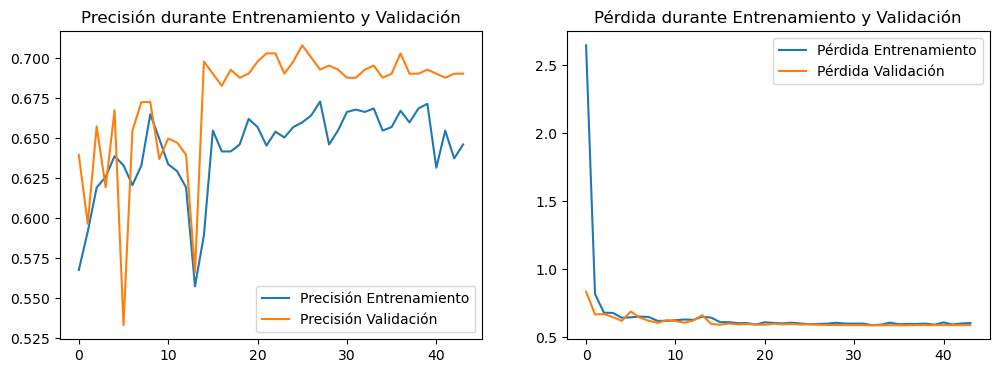

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


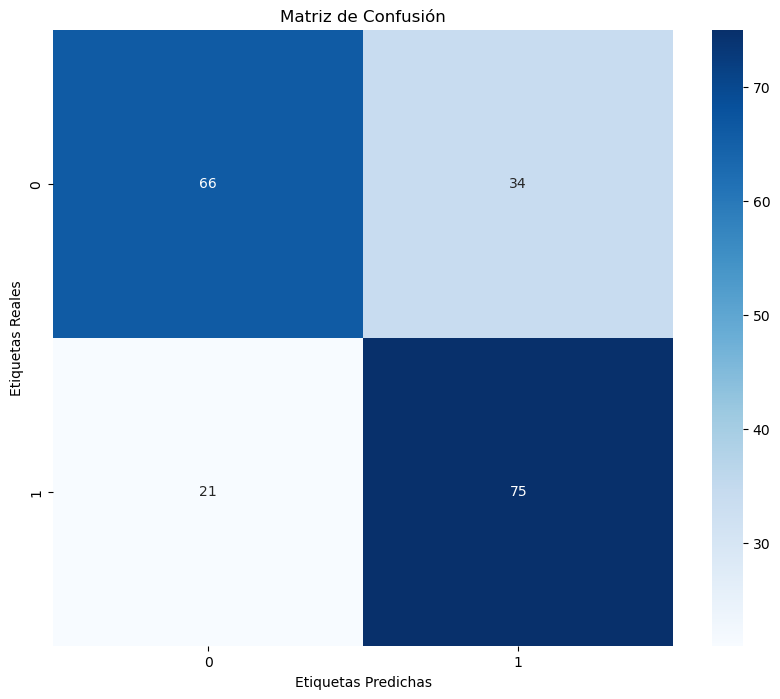

              precision    recall  f1-score   support

   not_pizza       0.76      0.66      0.71       100
       pizza       0.69      0.78      0.73        96

    accuracy                           0.72       196
   macro avg       0.72      0.72      0.72       196
weighted avg       0.72      0.72      0.72       196



In [11]:
# Visualización de la evolución del entrenamiento
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Precisión Entrenamiento')
plt.plot(epochs_range, val_acc, label='Precisión Validación')
plt.legend(loc='lower right')
plt.title('Precisión durante Entrenamiento y Validación')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Pérdida Entrenamiento')
plt.plot(epochs_range, val_loss, label='Pérdida Validación')
plt.legend(loc='upper right')
plt.title('Pérdida durante Entrenamiento y Validación')
plt.show()

from keras.models import load_model

# Cargar el mejor modelo guardado
best_model = load_model('best_model.h5')

# Evaluación en el conjunto de test
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

test_gen.reset()
predictions = best_model.predict(test_gen, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_test = test_gen.classes

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.ylabel('Etiquetas Reales')
plt.xlabel('Etiquetas Predichas')
plt.show()

# Reporte de Clasificación
print(classification_report(y_test, y_pred, target_names=pizza_categories))

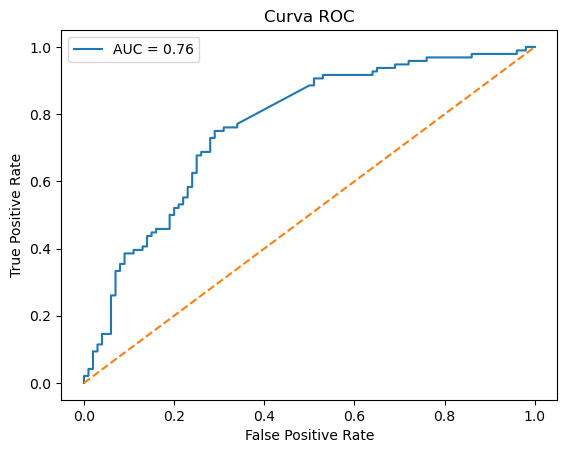

In [12]:
from sklearn.metrics import roc_curve, auc

# Probabilidades de la clase positiva (pizza)
y_prob = predictions[:, 1] if predictions.shape[1] > 1 else predictions

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()

**Análisis de Resultados**

1. Gráficos de Entrenamiento

Precisión:
- Inicia en ~0.57 y alcanza ~0.66-0.67 al final de las 44 épocas
- La brecha entre entrenamiento y validación es consistente, con validación ligeramente superior, indicando generalization adecuada
- Ambas métricas muestran crecimiento progresivo sin signos claros de overfitting severo, aunque la validación no es estable.

Pérdida:
- Desciende rápidamente desde ~2.6 a ~0.60 en los primeros epochs
- La pérdida de validación sigue un patrón similar, estabilizándose alrededor de 0.59
- Las curvas paralelas confirman que el modelo generaliza correctamente sin memorizar datos

2. Desempeño del Modelo

El modelo alcanzó un 72% de predicciones correctas en el conjunto de test:

Matriz de Confusión:
- **Clase No Pizza:** 66 verdaderos negativos, 34 falsos positivos
- **Clase Pizza:** 75 verdaderos positivos, 21 falsos negativos

Métricas por Clase:
- **Clase No Pizza:** Precision 0.76 | Recall 0.66 | F1-Score 0.71
- **Clase Pizza:** Precision 0.69 | Recall 0.78 | F1-Score 0.73

El F1-score similar entre clases (0.71 vs 0.73) indica balance adecuado sin sesgo significativo hacia una categoría, aunque la precisòn es mejor en la clase no pizza, el recall es mejor en la clase pizza.

3. Conclusiones

El modelo MLP demuestra capacidad discriminativa razonable para clasificación binaria, con desempeño moderado (~72% accuracy). La ausencia de overfitting severo sugiere capacidad de generalización a nuevas imágenes, aunque el rendimiento es inferior al esperado para una tarea binaria simple. La arquitectura es funcional pero con margen considerable de mejora.

4. Limitaciones y Posibles Mejoras

- Limitación de arquitectura: Los modelos MLP procesando imágenes no son la arquitectura óptima. Las CNNs podrían tener un desempeño mejor, ya que los datos de entrada son representaciones matriciales de imágenes.
- Aumentar capacidad del modelo mediante capas adicionales o mayor número de neuronas.
- Implementar transfer learning utilizando modelos preentrenados (ResNet, VGG).
- Optimizar hiperparámetros: ajustar learning rate, tasas de dropout, batch size.
- Incrementar el dataset de entrenamiento para mejorar robustez.

La curva ROC muestra una capacidad de discriminación moderada con AUC = 0.76, superior al azar (0.50). Hay margen de mejora, especialmente adoptando arquitecturas más adecuadas para imágenes como las CNNs.